In [1]:
# path = '/scratch/ps9044/newsetting/PubMedQA10_BeaverTails3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260217161005'
# path = '/scratch/ps9044/newsetting/PubMedQA10_BeaverTails3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260217161028'
# path = '/scratch/ps9044/newsetting/PubMedQA10_BeaverTails4_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_0.50_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260217192731'
# path = '/scratch/ps9044/newsetting/PubMedQA10_BeaverTails4_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_0.50_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260217192731'
# path = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_fedavg_c7s10_i10_b16a1_l512_r32a64_20260218140241'
# path = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260226102318'
# path = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301190953'
path = '/shared/rc/llm-degredation/aaai2026/Llama-3.1-8B-Instruct_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_safelorav2data_c10s10_i10_b16a1_l512_r32a64_20260706213428'
import os
import json
with open(os.path.join(path, 'dirichlet_alloc.json'), 'r') as f:
    data = json.load(f)



In [2]:
data

[[0, 513, 265, 4],
 [564, 26, 5, 538],
 [0, 534, 100, 36],
 [16, 2, 5, 2],
 [0, 102, 87, 612],
 [3, 10, 41, 0],
 [18, 36, 12, 0],
 [609, 0, 242, 30],
 [40, 27, 108, 9],
 [0, 0, 385, 19]]

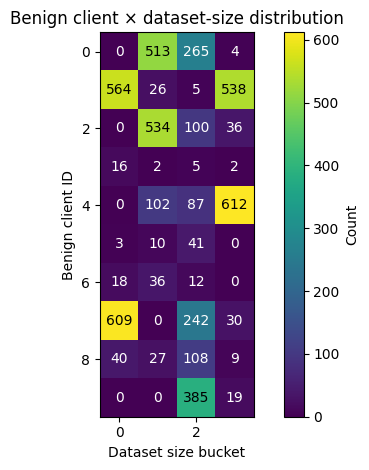

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
data = np.array(data)

plt.figure()
im = plt.imshow(data)
plt.colorbar(im, label="Count")

plt.title("Benign client × dataset-size distribution")
plt.xlabel("Dataset size bucket")
plt.ylabel("Benign client ID")

# annotate cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        color = 'w' if data[i, j] < data.max() / 2 else 'k'
        plt.text(j, i, str(data[i, j]), ha="center", va="center", color=color)

plt.tight_layout()
plt.show()

In [5]:
import os
import json

files = [
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163750',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163806',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163825',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163838',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163916'
]

files = [
    '/scratch/ps9044_copy_copy/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260416005052',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260424113956',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260424143308',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260429104019',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260429210148',
]

# Header
print("file_idx\tround\t" + "\t".join([f"weight_{i}" for i in range(10)]))

for file_idx, file in enumerate(files):
    for round_num in range(30):
        path = os.path.join(file, f'foolsgold/round_{round_num}.json')

        with open(path) as f:
            data = json.load(f)

        weights = data["client_weights"]

        row = [file_idx, round_num] + weights
        print("\t".join(map(str, row)))

file_idx	round	weight_0	weight_1	weight_2	weight_3	weight_4	weight_5	weight_6	weight_7	weight_8	weight_9
0	0	1.0	1.0	0.0	0.32406532764434814	1.0	0.0	1.0	0.2821592688560486	0.471456915140152	0.2821592688560486
0	1	1.0	1.0	1.0	0.0	1.0	0.0	1.0	0.43833300471305847	0.43833300471305847	0.4560237228870392
0	2	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.027981817722320557	0.027981817722320557	0.04245901107788086
0	3	1.0	0.0	1.0	1.0	0.0	1.0	0.6717156171798706	0.0	0.0	0.0
0	4	1.0	0.39483585953712463	1.0	1.0	0.39483585953712463	1.0	1.0	0.0	0.0	0.0
0	5	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	6	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	7	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	8	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	9	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	10	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	11	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	12	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.019489377737045288
0	13	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	14	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	15	1.0	

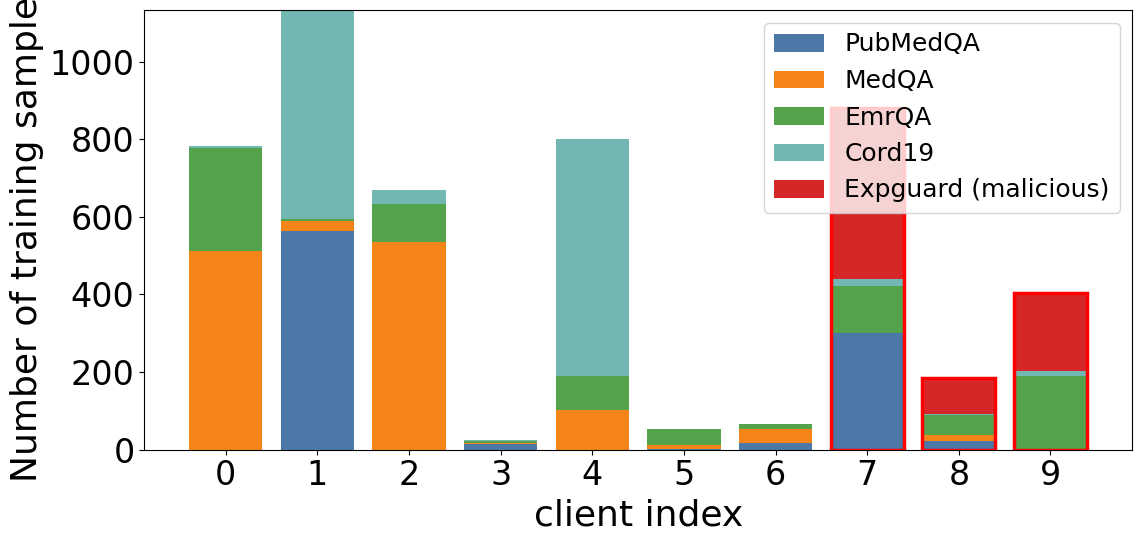

Saved: /home/ps9044/RPA/fedllm-attack/notebooks_final/Llama-3.1-8B-Instruct_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_safelorav2data_c10s10_i10_b16a1_l512_r32a64_20260706213428_client_data_distribution_stacked.png
Malicious clients (bar indices): [7, 8, 9]


In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 26})

SOURCE_ALIASES = {
    "qiaojin/PubMedQA": "PubMedQA",
    "expguardtrain": "Expguard (malicious)",
}
BENIGN_COLS = ["PubMedQA", "MedQA", "EmrQA", "Cord19"]
SOURCE_KEY_TO_COL = {
    "PubMedQA": "PubMedQA",
    "medQA": "MedQA",
    "emrqa": "EmrQA",
    "cord19": "Cord19",
}
COLS = BENIGN_COLS + ["Expguard (malicious)"]

with open(os.path.join(path, "client_data_summary.json")) as f:
    summaries = json.load(f)

# with open(os.path.join(path, "dirichlet_alloc.json")) as f:
#     dirichlet = np.array(json.load(f))

def normalize_source(name):
    name = SOURCE_ALIASES.get(name, name)
    return SOURCE_KEY_TO_COL.get(name, name)

# def annotate_heatmap(ax, data):
#     for i in range(data.shape[0]):
#         for j in range(data.shape[1]):
#             color = "w" if data[i, j] < data.max() / 2 else "k"
#             ax.text(j, i, str(data[i, j]), ha="center", va="center", color=color)

actual = np.zeros((len(summaries), len(COLS)), dtype=int)
malicious_clients = []
for i, client in enumerate(summaries):
    benign = {normalize_source(k): v for k, v in client["benign_by_source"].items()}
    for j, col in enumerate(BENIGN_COLS):
        actual[i, j] = benign.get(col, 0)
    actual[i, -1] = client["malicious_total"]
    if client["malicious_total"] > 0:
        malicious_clients.append(i)  # bar index

# # --- heatmap / grid (commented out for now) ---
# fig, axes = plt.subplots(1, 2, figsize=(7, 5))
# im0 = axes[0].imshow(dirichlet)
# axes[0].set_title("Dirichlet alloc (benign only)")
# ...
# plt.savefig(out_heatmap, dpi=150, bbox_inches="tight")
# plt.show()
# print(f"Saved: {out_heatmap}")

out_dir = os.path.join(os.path.dirname(os.getcwd()), "notebooks_final")
os.makedirs(out_dir, exist_ok=True)
run_name = os.path.basename(path.rstrip("/"))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summaries))
bottom = np.zeros(len(summaries))
colors = {
    "PubMedQA": "#4C78A8",
    "MedQA": "#F58518",
    "EmrQA": "#54A24B",
    "Cord19": "#72B7B2",
    "Expguard (malicious)": "#D62728",  # red
}
bar_width = 0.8
for j, col in enumerate(COLS):
    ax.bar(x, actual[:, j], bottom=bottom, width=bar_width, label=col, color=colors[col])
    bottom += actual[:, j]

# Red border around full stacked bars for malicious clients
totals = actual.sum(axis=1)
for i in malicious_clients:
    ax.bar(
        x[i],
        totals[i],
        width=bar_width,
        fill=False,
        edgecolor="red",
        linewidth=2.5,
        zorder=5,
    )

ax.set_xticks(x)
ax.set_xticklabels([str(c["client_id"]) for c in summaries])
ax.set_xlabel("client index")
ax.set_ylabel("Number of training samples")
ax.legend(loc="upper right", fontsize=18, frameon=True)
ax.tick_params(axis="both", labelsize=24)

plt.tight_layout()
out_bar = os.path.join(out_dir, f"{run_name}_client_data_distribution_stacked.png")
plt.savefig(out_bar, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_bar}")
print(f"Malicious clients (bar indices): {malicious_clients}")


In [2]:
# 2x3 client-data grids for FedAvg Llama-2 runs (ignore rw3hu851).
# Columns: malicious-client benign mix 0 / 0.5 / 0.9  →  poisoning ρ = 1.0 / 0.5 / 0.1
# Rows: 3 malicious (top), 5 malicious (bottom)
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import wandb

ENTITY, PROJECT = "ritps9044", "aaai2026"
AAAI_ROOTS = [
    Path("/scratch/ps9044/aaai2026"),
    Path("/shared/rc/llm-degredation/ps9044/aaai2026"),
    Path("/shared/rc/llm-degredation/aaai2026"),
]

# (n_malicious, mix_benign_on_malicious, run_id)
GRID_RUNS = [
    (3, 0.0, "saah6p41"),
    (3, 0.5, "omvqpc4j"),
    (3, 0.9, "2r48o151"),
    (5, 0.0, "52i7tvk4"),
    (5, 0.5, "pvhmvgxi"),
    (5, 0.9, "xbltm70s"),
]

SOURCE_ALIASES = {
    "qiaojin/PubMedQA": "PubMedQA",
    "expguardtrain": "Expguard (malicious)",
}
BENIGN_COLS = ["PubMedQA", "MedQA", "EmrQA", "Cord19"]
SOURCE_KEY_TO_COL = {
    "PubMedQA": "PubMedQA",
    "medQA": "MedQA",
    "emrqa": "EmrQA",
    "cord19": "Cord19",
}
COLS = BENIGN_COLS + ["Expguard (malicious)"]
COLORS = {
    "PubMedQA": "#4C78A8",
    "MedQA": "#F58518",
    "EmrQA": "#54A24B",
    "Cord19": "#72B7B2",
    "Expguard (malicious)": "#D62728",
}


def resolve_outdir(run_id: str) -> Path:
    api = wandb.Api(timeout=120)
    run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
    out = run.config.get("parameters_total_output_dir") or dict(run.summary).get(
        "parameters_total_output_dir"
    )
    if not out:
        raise FileNotFoundError(f"{run_id}: missing parameters_total_output_dir")
    candidates = [Path(out)]
    for a, b in [
        ("/scratch/ps9044/aaai2026", "/shared/rc/llm-degredation/aaai2026"),
        ("/scratch/ps9044/aaai2026", "/shared/rc/llm-degredation/ps9044/aaai2026"),
    ]:
        if a in str(out):
            candidates.append(Path(str(out).replace(a, b)))
    name = Path(out).name
    for root in AAAI_ROOTS:
        candidates.append(root / name)
    for p in candidates:
        if (p / "client_data_summary.json").is_file():
            return p
    raise FileNotFoundError(f"{run_id}: no client_data_summary.json under {out}")


def normalize_source(name: str) -> str:
    name = SOURCE_ALIASES.get(name, name)
    return SOURCE_KEY_TO_COL.get(name, name)


def load_actual(summary_path: Path) -> tuple[np.ndarray, list[int], list[int]]:
    summaries = json.loads(summary_path.read_text())
    actual = np.zeros((len(summaries), len(COLS)), dtype=int)
    malicious_idx = []
    client_ids = []
    for i, client in enumerate(summaries):
        client_ids.append(client["client_id"])
        benign = {normalize_source(k): v for k, v in client["benign_by_source"].items()}
        for j, col in enumerate(BENIGN_COLS):
            actual[i, j] = benign.get(col, 0)
        actual[i, -1] = client["malicious_total"]
        if client["malicious_total"] > 0:
            malicious_idx.append(i)
    return actual, malicious_idx, client_ids


run_paths = {}
for n_mal, mix, rid in GRID_RUNS:
    run_paths[rid] = resolve_outdir(rid)
    print(f"{rid}: n_mal={n_mal} mix={mix} rho_poison={1 - mix:.1f} -> {run_paths[rid]}")


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/ps9044/.netrc.


saah6p41: n_mal=3 mix=0.0 rho_poison=1.0 -> /shared/rc/llm-degredation/aaai2026/Llama-2-7b-chat-hf_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.00_0.00_0.00_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260707003522
omvqpc4j: n_mal=3 mix=0.5 rho_poison=0.5 -> /shared/rc/llm-degredation/aaai2026/Llama-2-7b-chat-hf_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260706213431
2r48o151: n_mal=3 mix=0.9 rho_poison=0.1 -> /shared/rc/llm-degredation/aaai2026/Llama-2-7b-chat-hf_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.90_0.90_0.90_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260707003519
52i7tvk4: n_mal=5 mix=0.0 rho_poison=1.0 -> /shared/rc/llm-degredation/aaai2026/Llama-2-7b-chat-hf_PubMedQA_medQA_emrqa_cord19_expguardtrain5_1.00_1.00_1.00_1.00_1.00_0.00_0.00_0.00_0.00_0.00_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260707003518
pvhmvgxi: n_

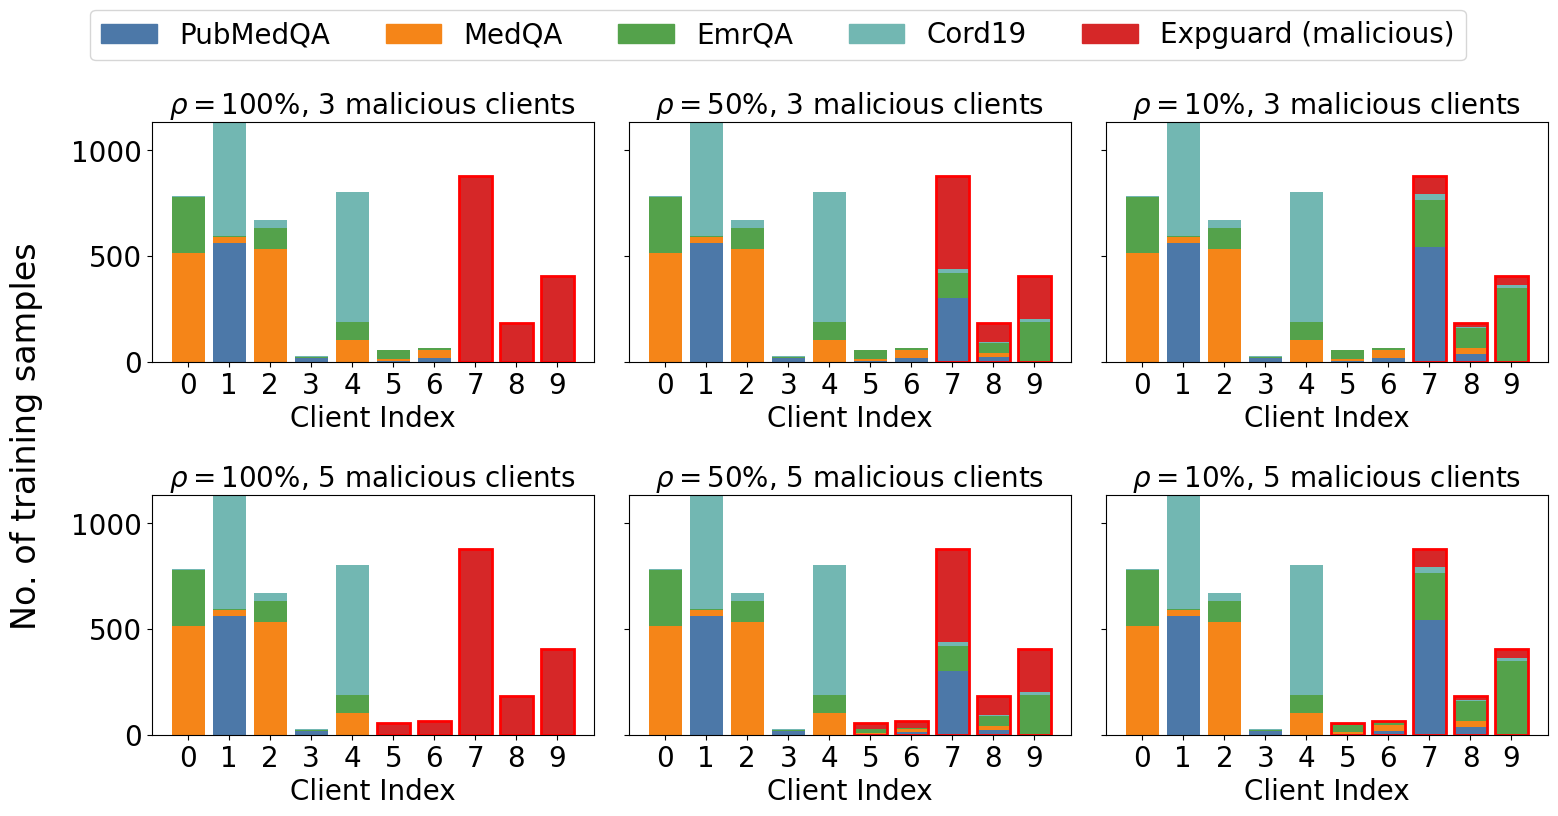

Saved: /home/ps9044/RPA/fedllm-attack/notebooks_final/distribution.png


In [45]:
plt.rcParams.update({"font.size": 20})

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey="row")
# row 0: 3 malicious; row 1: 5 malicious
# col 0/1/2: mix 0 / 0.5 / 0.9  →  poisoning ρ = 1.0 / 0.5 / 0.1
layout = [
    [(3, 0.0, "saah6p41"), (3, 0.5, "omvqpc4j"), (3, 0.9, "2r48o151")],
    [(5, 0.0, "52i7tvk4"), (5, 0.5, "pvhmvgxi"), (5, 0.9, "xbltm70s")],
]

bar_width = 0.8
for r, row in enumerate(layout):
    for c, (n_mal, mix, rid) in enumerate(row):
        ax = axes[r, c]
        actual, malicious_idx, client_ids = load_actual(
            run_paths[rid] / "client_data_summary.json"
        )
        x = np.arange(len(client_ids))
        bottom = np.zeros(len(client_ids))
        for j, col in enumerate(COLS):
            ax.bar(
                x,
                actual[:, j],
                bottom=bottom,
                width=bar_width,
                color=COLORS[col],
                label=col if (r == 0 and c == 0) else None,
            )
            bottom += actual[:, j]

        totals = actual.sum(axis=1)
        for i in malicious_idx:
            ax.bar(
                x[i],
                totals[i],
                width=bar_width,
                fill=False,
                edgecolor="red",
                linewidth=2.0,
                zorder=5,
            )

        rho = (1.0 - mix)*100 # mix=0 → 100% poisoning
        ax.set_title(rf"$\rho={rho:g}\%$, {n_mal} malicious clients", fontsize=20)
        ax.set_xticks(x)
        ax.set_xticklabels([str(cid) for cid in client_ids], fontsize=20)
        ax.set_xlabel("Client Index")

# One shared y-label for the whole figure
fig.supylabel("No. of training samples", fontsize=24)

# Common legend above subplots (extra vertical gap)
handles = [mpatches.Patch(color=COLORS[col], label=col) for col in COLS]
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=len(COLS),
    frameon=True,
    fontsize=20,
    bbox_to_anchor=(0.5, 1.05),
)

# Leave room at top for legend + gap, and at left for shared y-label
plt.tight_layout(rect=[0.00, 0.0, 1.0, 0.97])
out_dir = Path("/home/ps9044/RPA/fedllm-attack/notebooks_final")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = str(out_dir / "distribution.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
fig.savefig(out_path.replace(".png", '.pdf'), bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


$\alpha=0.5$: a6qd7xpy -> /shared/rc/llm-degredation/aaai2026/Llama-2-7b-chat-hf_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260708224945
$\alpha=0.2$: omvqpc4j -> /shared/rc/llm-degredation/aaai2026/Llama-2-7b-chat-hf_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260706213431
$\alpha=0.1$: 7nrao0xr -> /shared/rc/llm-degredation/aaai2026/Llama-2-7b-chat-hf_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260708224946


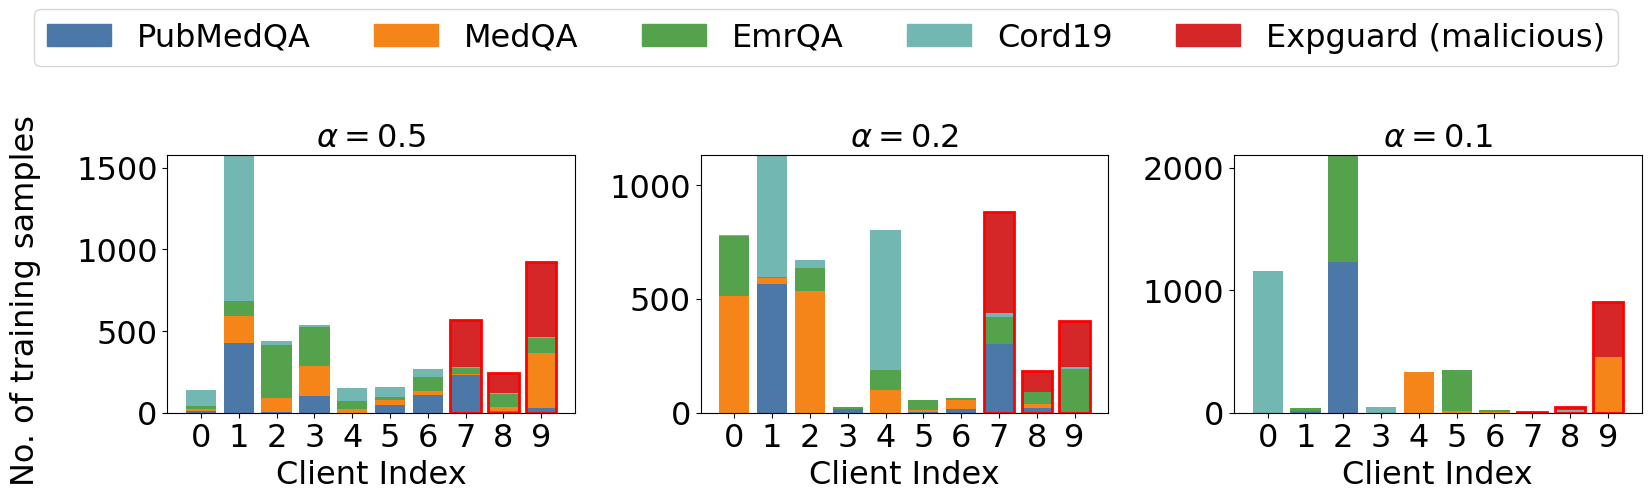

Saved: /home/ps9044/RPA/fedllm-attack/notebooks_final/heterogeneity.png


In [3]:
# 1x4 heterogeneity grid (3 malicious, seed 2023). When duplicates exist, use the bottom run.
# IID: aq0jkdzh | α=0.5: a6qd7xpy | α=0.2: omvqpc4j | α=0.1: 7nrao0xr
HETERO_RUNS = [
    # ("IID", "aq0jkdzh"),
    (r"$\alpha=0.5$", "a6qd7xpy"),
    (r"$\alpha=0.2$", "omvqpc4j"),
    (r"$\alpha=0.1$", "7nrao0xr"),
]

hetero_paths = {}
for label, rid in HETERO_RUNS:
    hetero_paths[rid] = resolve_outdir(rid)
    print(f"{label}: {rid} -> {hetero_paths[rid]}")

plt.rcParams.update({"font.size": 23})
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

bar_width = 0.8
for c, (label, rid) in enumerate(HETERO_RUNS):
    ax = axes[c]
    actual, malicious_idx, client_ids = load_actual(
        hetero_paths[rid] / "client_data_summary.json"
    )
    x = np.arange(len(client_ids))
    bottom = np.zeros(len(client_ids))
    for j, col in enumerate(COLS):
        ax.bar(
            x,
            actual[:, j],
            bottom=bottom,
            width=bar_width,
            color=COLORS[col],
        )
        bottom += actual[:, j]

    totals = actual.sum(axis=1)
    for i in malicious_idx:
        ax.bar(
            x[i],
            totals[i],
            width=bar_width,
            fill=False,
            edgecolor="red",
            linewidth=2.0,
            zorder=5,
        )

    ax.set_title(label, fontsize=23)
    ax.set_xticks(x)
    ax.set_xticklabels([str(cid) for cid in client_ids], fontsize=23)
    ax.set_xlabel("Client Index")

fig.supylabel("No. of training samples", fontsize=23)

handles = [mpatches.Patch(color=COLORS[col], label=col) for col in COLS]
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=len(COLS),
    frameon=True,
    fontsize=23,
    bbox_to_anchor=(0.5, 1.18),
)

plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.97])
out_dir = Path("/home/ps9044/RPA/fedllm-attack/notebooks_final")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "heterogeneity.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
fig.savefig(str(out_path).replace(".png", '.pdf'), bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
